In [ ]:
import gdown
import os

os.makedirs('./datasets', exist_ok=True)
gdown.download_folder('https://drive.google.com/drive/folders/1Rc2Rx4ZCr9np753boGGh03JOl82VpFxT?usp=sharing', output='./datasets', quiet=False)

Retrieving folder contents


Processing file 13vG16tE9mA6jAnvWtPucvWb-YOfdzdIK burma14.tsp
Processing file 1nZEo-kKOURdxlxFHBf-o2RbdJlWKVA3x d2103.tsp
Processing file 1j0JAUwRDroRX5eqNVQejlv2RkInHucy6 fl417.tsp
Processing file 1VkiHKpVf7BNt4HrVFXYyzavpztq6zX7H gr17.tsp
Processing file 15MJJ7GkaRBhZ7MH0v3z5VRxYzx_9o8B0 lin105.tsp
Processing file 1gyFcIKorprjIgO_FIismGlCkSZKaDsyv pla7397.tsp
Processing file 1DSyPPG2X7EO5KNgWZ3YOpjv9NrdWrdaI pr1002.tsp
Processing file 1c4FrA68jsFtk8BX4qyDLqw-G8AyXYcAL u574.tsp


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=13vG16tE9mA6jAnvWtPucvWb-YOfdzdIK
To: /content/datasets/burma14.tsp
100%|██████████| 524/524 [00:00<00:00, 2.58MB/s]
Downloading...
From: https://drive.google.com/uc?id=1nZEo-kKOURdxlxFHBf-o2RbdJlWKVA3x
To: /content/datasets/d2103.tsp
100%|██████████| 60.0k/60.0k [00:00<00:00, 10.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1j0JAUwRDroRX5eqNVQejlv2RkInHucy6
To: /content/datasets/fl417.tsp
100%|██████████| 11.7k/11.7k [00:00<00:00, 27.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1VkiHKpVf7BNt4HrVFXYyzavpztq6zX7H
To: /content/datasets/gr17.tsp
100%|██████████| 730/730 [00:00<00:00, 1.39MB/s]
Downloading...
From: https://drive.google.com/uc?id=15MJJ7GkaRBhZ7MH0v3z5VRxYzx_9o8B0
To: /content/datasets/lin105.tsp
100%|██████████| 1.36k/1.36k [00:00<00:00, 6.86MB/s]
Downloading...
From: https://drive.google.com/

In [ ]:
import os, time, math
import numpy as np
from scipy.spatial.distance import cdist

In [ ]:
#Define dataset path, random seeds for testing, and known optimal answers to benchmark against
DATASET_DIR = './datasets/'
SEEDS = [11, 22, 33, 44, 55]

OPTIMAL_VALUES = {
    'burma14.tsp' : 3323,
    'gr17.tsp' : 2085,
    'lin105.tsp' : 14379,
    'fl417.tsp' : 11861,
    'u574.tsp' : 36905,
    'pr1002.tsp' : 259045,
    'd2103.tsp' : 80450,
    'pla7397.tsp' : 23260728,
}

print("Config ready!")

Config ready!


#READ DATASETS

In [ ]:
#Define read_tsp() - parse a .tsp file into usable data

#Read a .tsp file and extract city coordinates or distance matrix into a dictionary
def read_tsp(filepath):
    #Initialize empty containers
    coords = {}
    edge_weights = []
    edge_weight_type = None
    edge_weight_format = None
    dimension = None
    reading_coords = False
    reading_weights = False

    #Read all lines from file
    with open(filepath, "r") as f:
        lines = f.readlines()

    #Parse line by line
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        #Read header metadata
        if line.startswith("DIMENSION"):
            dimension = int(line.split(":")[1].strip())
        elif line.startswith("EDGE_WEIGHT_TYPE"):
            edge_weight_type = line.split(":")[1].strip()
        elif line.startswith("EDGE_WEIGHT_FORMAT"):
            edge_weight_format = line.split(":")[1].strip()
        #Detect section markers
        elif line == "NODE_COORD_SECTION":
            reading_coords = True;  reading_weights = False
        elif line == "EDGE_WEIGHT_SECTION":
            reading_weights = True; reading_coords = False
        elif line in ("EOF", "DISPLAY_DATA_SECTION"):
            reading_coords = False; reading_weights = False
        #Read actual data
        elif reading_coords and line:
            parts = line.split()
            node = int(parts[0]) - 1
            coords[node] = (float(parts[1]), float(parts[2]))
        elif reading_weights and line:
            edge_weights.extend([int(x) for x in line.split()])
        i += 1

    #Convert coords dict into numpy array (or None if no coords)
    coords_arr = np.array([coords[k] for k in range(len(coords))]) if coords else None
    #Return as a dictionary
    return {
        "coords" : coords_arr,
        "edge_weights" : edge_weights,
        "edge_weight_type" : edge_weight_type,
        "edge_weight_format" : edge_weight_format,
        "dimension" : dimension,
    }

print("Read_tsp ready!")

Read_tsp ready!


#DISTANCE MATRIX BUIDING

In [ ]:
#Convert raw TSP data into a full N×N distance matrix based on the distance type (EXPLICIT or formula-based)
def build_dist_matrix(data):
    ewt = data["edge_weight_type"]
    ewf = data["edge_weight_format"]
    coords = data["coords"]
    n = data["dimension"]
    values = data["edge_weights"]

    #Case1: distances are already given as a matrix, just need to reshape
    if ewt == "EXPLICIT":
        dist = np.zeros((n, n), dtype=np.int32)
        if ewf == "FULL_MATRIX":
            dist = np.array(values, dtype=np.int32).reshape(n, n)
        elif ewf in ("UPPER_ROW", "UPPER_DIAG_ROW"):
            idx = 0; start = 1 if ewf == "UPPER_ROW" else 0
            for i in range(n):
                for j in range(i + start, n):
                    dist[i][j] = dist[j][i] = values[idx]; idx += 1
        elif ewf in ("LOWER_ROW", "LOWER_DIAG_ROW"):
            idx = 0; start = 1 if ewf == "LOWER_ROW" else 0
            for i in range(start, n):
                for j in range(0, i + (0 if ewf == "LOWER_ROW" else 1)):
                    dist[i][j] = dist[j][i] = values[idx]; idx += 1
        elif ewf == "UPPER_COL":
            idx = 0
            for j in range(n):
                for i in range(j):
                    dist[i][j] = dist[j][i] = values[idx]; idx += 1
        elif ewf == "LOWER_COL":
            idx = 0
            for j in range(n):
                for i in range(j+1, n):
                    dist[i][j] = dist[j][i] = values[idx]; idx += 1
        np.fill_diagonal(dist, 0)
        return dist

    #Case2: calculate distances from coordinates using different formulas
    if ewt in ("EUC_2D", "EUC_3D"):
        dist = (cdist(coords, coords, metric='euclidean') + 0.5).astype(np.int32)
    elif ewt == "CEIL_2D":
        dist = np.ceil(cdist(coords, coords, metric='euclidean')).astype(np.int32)
    elif ewt == "MAN_2D":
        dist = (cdist(coords, coords, metric='cityblock') + 0.5).astype(np.int32)
    elif ewt == "MAX_2D":
        dist = (cdist(coords, coords, metric='chebyshev') + 0.5).astype(np.int32)
    elif ewt == "GEO":
        def to_rad(c):
            deg = int(c); return math.pi * (deg + 5*(c-deg)/3) / 180
        RRR = 6378.388
        dist = np.zeros((n, n), dtype=np.int32)
        for i in range(n):
            for j in range(i+1, n):
                lat1,lon1 = to_rad(coords[i][0]), to_rad(coords[i][1])
                lat2,lon2 = to_rad(coords[j][0]), to_rad(coords[j][1])
                q1 = math.cos(lon1-lon2); q2 = math.cos(lat1-lat2); q3 = math.cos(lat1+lat2)
                d = int(RRR * math.acos(max(-1, min(1, 0.5*((1+q1)*q2-(1-q1)*q3)))) + 1)
                dist[i][j] = dist[j][i] = d
    elif ewt == "ATT":
        dist = np.zeros((n, n), dtype=np.int32)
        for i in range(n):
            for j in range(i+1, n):
                dx = coords[i][0]-coords[j][0]; dy = coords[i][1]-coords[j][1]
                r = math.sqrt((dx**2+dy**2)/10.0); t = int(r)
                dist[i][j] = dist[j][i] = t+1 if t < r else t
    else:
        print(f"  [WARN] Not supported yet! '{ewt}', fallback EUC_2D")
        dist = (cdist(coords, coords, metric='euclidean') + 0.5).astype(np.int32)

    np.fill_diagonal(dist, 0)
    return dist

print("Build_dist_matrix ready!")

Build_dist_matrix ready!


##HELPER FUNCTIONS

In [ ]:
#Define three utility functions used throughout the notebook: calculate route distance, validate a tour, and measure solution quality
def total_distance(route, dist_matrix):
    arr = np.asarray(route, dtype=np.int64)
    return int(dist_matrix.astype(np.int64)[arr, np.roll(arr, -1)].sum())

def is_valid_tour(route, n):
    return (len(route) == n and len(set(route)) == n
            and min(route) >= 0 and max(route) < n)

def calc_gap(cost, optimal):
    return round((cost - optimal) / optimal * 100, 4)

print("Helper functions ready!")

Helper functions ready!


#DATASET INFORMATIONS

In [ ]:
all_files = sorted(OPTIMAL_VALUES.keys(),
                   key=lambda f: read_tsp(os.path.join(DATASET_DIR, f))["dimension"])
#Split all loaded TSP files into 2 groups: ones with raw coordinates vs ones with pre-calculated distances
coord_files = []
explicit_files = []

for fname in all_files:
    data = read_tsp(os.path.join(DATASET_DIR, fname))
    if data['edge_weight_type'] == 'EXPLICIT':
        explicit_files.append((fname, data))
    else:
        coord_files.append((fname, data))

In [ ]:
#Print a formatted table showing key information for each coordinate-based TSP file
print(f"{'COORDINATE-BASED DATASETS':^90}")
print("-"*90)
print(f"  {'File':<15} {'N':>5} {'Type':>8} {'Optimal':>12} {'X range':>20} {'Y range':>20} {'Group':>8}")
print(f"  {'─'*15} {'─'*5} {'─'*8} {'─'*12} {'─'*20} {'─'*20} {'─'*8}")

for fname, data in coord_files:
    n = data['dimension']
    ewt = data['edge_weight_type']
    optimal = OPTIMAL_VALUES[fname]
    coords = data['coords']
    x_range = f"[{coords[:,0].min():.1f}, {coords[:,0].max():.1f}]"
    y_range = f"[{coords[:,1].min():.1f}, {coords[:,1].max():.1f}]"

    if n <= 29:
      group = 'Tiny'
    elif n <= 100:
      group = 'Small'
    elif n <= 500:
      group = 'Medium'
    elif n <= 2000:
      group = 'Large'
    else:
      group = 'XLarge'

    print(f"  {fname:<15} {n:>5} {ewt:>8} {optimal:>12,} {x_range:>20} {y_range:>20} {group:>8}")

print("-"*90)

                                COORDINATE-BASED DATASETS                                 
------------------------------------------------------------------------------------------
  File                N     Type      Optimal              X range              Y range    Group
  ─────────────── ───── ──────── ──────────── ──────────────────── ──────────────────── ────────
  burma14.tsp        14      GEO        3,323         [14.1, 25.2]         [92.5, 98.1]     Tiny
  lin105.tsp        105   EUC_2D       14,379       [63.0, 3087.0]       [69.0, 1276.0]   Medium
  fl417.tsp         417   EUC_2D       11,861      [511.4, 1894.7]      [152.5, 2048.1]   Medium
  u574.tsp          574   EUC_2D       36,905      [492.0, 3564.0]      [606.8, 2345.3]    Large
  pr1002.tsp       1002   EUC_2D      259,045    [1050.0, 16850.0]    [1450.0, 11650.0]    Large
  d2103.tsp        2103   EUC_2D       80,450        [0.0, 4348.2]        [0.0, 3263.4]   XLarge
  pla7397.tsp      7397  CEIL_2D   23,260,

In [ ]:
#Print a formatted table showing key information for explicit datasets — no coordinate ranges since distances are pre-calculated
print(f"{'EXPLICIT DATASETS':^65}")
print("-"*65)
print(f"  {'File':<15} {'N':>5} {'Format':<20} {'Optimal':>12} {'Group':>8}")
print(f"  {'─'*15} {'─'*5} {'─'*20} {'─'*12} {'─'*8}")

for fname, data in explicit_files:
    n = data['dimension']
    ewf = data['edge_weight_format']
    optimal = OPTIMAL_VALUES[fname]

    if n <= 29:
      group = 'Tiny'
    elif n <= 100:
      group = 'Small'
    elif n <= 500:
      group = 'Medium'
    elif n <= 2000:
      group = 'Large'
    else:
      group = 'XLarge'

    print(f"  {fname:<15} {n:>5} {ewf:<20} {optimal:>12,} {group:>8}")

print("-"*65)

                        EXPLICIT DATASETS                        
-----------------------------------------------------------------
  File                N Format                    Optimal    Group
  ─────────────── ───── ──────────────────── ──────────── ────────
  gr17.tsp           17 LOWER_DIAG_ROW              2,085     Tiny
-----------------------------------------------------------------


In [ ]:
#Print one unified table for all datasets (both coordinate and explicit) with total count at the bottom
print(f"{'DATASET INFORMATION':^65}")
print("-"*65)
print(f"  {'File':<15} {'N':>6} {'Optimal':>12} {'Type':>10} {'Group':>10}")
print(f"  {'─'*15} {'─'*6} {'─'*12} {'─'*10} {'─'*10}")

for fname in all_files:
    data = read_tsp(os.path.join(DATASET_DIR, fname))
    n = data["dimension"]
    ewt = data["edge_weight_type"]
    optimal = OPTIMAL_VALUES[fname]

    if n <= 29:
      group = 'Tiny'
    elif n <= 100:
      group = 'Small'
    elif n <= 500:
      group = 'Medium'
    elif n <= 2000:
      group = 'Large'
    else:
      group = 'XLarge'

    print(f"  {fname:<15} {n:>6} {optimal:>12,} {ewt:>10} {group:>10}")

print("-"*65)
print(f"  Total dataset: {len(all_files)}")

                       DATASET INFORMATION                       
-----------------------------------------------------------------
  File                 N      Optimal       Type      Group
  ─────────────── ────── ──────────── ────────── ──────────
  burma14.tsp         14        3,323        GEO       Tiny
  gr17.tsp            17        2,085   EXPLICIT       Tiny
  lin105.tsp         105       14,379     EUC_2D     Medium
  fl417.tsp          417       11,861     EUC_2D     Medium
  u574.tsp           574       36,905     EUC_2D      Large
  pr1002.tsp        1002      259,045     EUC_2D      Large
  d2103.tsp         2103       80,450     EUC_2D     XLarge
  pla7397.tsp       7397   23,260,728    CEIL_2D     XLarge
-----------------------------------------------------------------
  Total dataset: 8


#FARTHEST INSERTION

In [ ]:
#Pick diverse starting cities by using the convex hull (outer boundary) of the map first, then inner cities
def convex_hull_starts(coords, n, max_starts):
    try:
        from scipy.spatial import ConvexHull
        hull = ConvexHull(coords)
        hull_pts = list(hull.vertices)
        centroid = coords.mean(axis=0)
        dists_to_center = np.linalg.norm(coords - centroid, axis=1)
        inner = [i for i in np.argsort(dists_to_center)[::-1] if i not in hull_pts]
        candidates = hull_pts + inner
        step = max(1, len(candidates) // max_starts)
        return candidates[::step][:max_starts]
    except:
        return list(range(max_starts))

In [ ]:
#Build a good initial TSP tour by repeatedly inserting the farthest unvisited city into the best position
def greedy_farthest_insertion(dist_matrix, coords=None):
    n = dist_matrix.shape[0]

    #Scale number of starting points based on problem size (bigger n = fewer starts to save time)
    if n <= 50:
      max_starts = n
    elif n <= 200:
      max_starts = 50
    elif n <= 500:
      max_starts = 30
    elif n <= 2000:
      max_starts = 15
    elif n <= 5000:
      max_starts = 8
    else:
      max_starts = 5

    #Pick starting cities: use convex hull if coords available, else pick cities with highest/lowest total distances
    if coords is not None and n >= 3:
        starts = convex_hull_starts(coords, n, max_starts)
    else:
        row_sums = dist_matrix.sum(axis=1)
        top = list(np.argsort(row_sums)[::-1][:max_starts//2 + 1])
        bottom = list(np.argsort(row_sums)[:max_starts//2 + 1])
        starts = list(set(top + bottom))[:max_starts]

    best_tour = None
    best_dist = float('inf')

    for start in starts:
        #Build tour from this starting city
        farthest = int(np.argmax(dist_matrix[start]))
        tour = [start, farthest]
        visited = np.zeros(n, dtype=bool)
        visited[start] = visited[farthest] = True
        nearest_dist = np.minimum(dist_matrix[:, start], dist_matrix[:, farthest])

        while len(tour) < n:
            masked = np.where(visited, -np.inf, nearest_dist)
            new_city = int(np.argmax(masked))
            #Find the best position to insert new_city
            tour_arr = np.array(tour, dtype=np.int32)
            next_arr = np.roll(tour_arr, -1)
            increases = (dist_matrix[tour_arr, new_city]
                       + dist_matrix[new_city, next_arr]
                       - dist_matrix[tour_arr, next_arr])
            best_pos = int(np.argmin(increases)) + 1
            tour.insert(best_pos, new_city)
            visited[new_city] = True
            nearest_dist = np.minimum(nearest_dist, dist_matrix[:, new_city])

        d = total_distance(tour, dist_matrix)
        if d < best_dist:
            best_dist = d
            best_tour = tour[:]

    return best_tour, best_dist

print("Greedy_farthest_insertion ready!")

Greedy_farthest_insertion ready!


In [ ]:
#Sort all datasets from smallest to largest, run greedy_farthest_insertion on each, and print performance summary
all_files = sorted(OPTIMAL_VALUES.keys(),
                   key=lambda f: read_tsp(os.path.join(DATASET_DIR, f))["dimension"])

print(f"Total file: {len(all_files)}")
print(f"Execution order: {all_files}\n")

for idx, fname in enumerate(all_files, start=1):
    print(f"{'-'*55}")
    print(f"[{idx}/{len(all_files)}] --> {fname}")
    print(f"{'-'*55}")

    data = read_tsp(os.path.join(DATASET_DIR, fname))
    dist_matrix = build_dist_matrix(data)
    n = data["dimension"]
    coords = data["coords"]
    optimal = OPTIMAL_VALUES[fname]

    t0 = time.time()
    fi_tour, fi_cost = greedy_farthest_insertion(dist_matrix, coords)
    fi_time = round(time.time() - t0, 3)

    print(f"  Optimal : {optimal:,}")
    print(f"  FI cost : {fi_cost:,}")
    print(f"  FI gap  : {calc_gap(fi_cost, optimal)}%")
    print(f"  FI time : {fi_time}s")
    print(f"  Valid   : {is_valid_tour(fi_tour, n)} ✓\n")

print("Pipeline FI: Done!")

Total file: 8
Execution order: ['burma14.tsp', 'gr17.tsp', 'lin105.tsp', 'fl417.tsp', 'u574.tsp', 'pr1002.tsp', 'd2103.tsp', 'pla7397.tsp']

-------------------------------------------------------
[1/8] --> burma14.tsp
-------------------------------------------------------
  Optimal : 3,323
  FI cost : 3,323
  FI gap  : 0.0%
  FI time : 0.01s
  Valid   : True ✓

-------------------------------------------------------
[2/8] --> gr17.tsp
-------------------------------------------------------
  Optimal : 2,085
  FI cost : 2,085
  FI gap  : 0.0%
  FI time : 0.009s
  Valid   : True ✓

-------------------------------------------------------
[3/8] --> lin105.tsp
-------------------------------------------------------
  Optimal : 14,379
  FI cost : 14,659
  FI gap  : 1.9473%
  FI time : 0.164s
  Valid   : True ✓

-------------------------------------------------------
[4/8] --> fl417.tsp
-------------------------------------------------------
  Optimal : 11,861
  FI cost : 12,232
  FI gap  :

#LOCAL SEARCH: SWAP

In [ ]:
#RANDOM TOUR PERTURBATION

#Break the tour into 4 segments and reconnect in a shuffled order to escape local optima
def double_bridge(tour, n):
    cuts = sorted(np.random.choice(range(1, n), size=3, replace=False))
    a, b, c = cuts
    return np.concatenate([tour[:a], tour[b:c], tour[a:b], tour[c:]])

In [ ]:
#IMPROVE TOUR VIA SWAP AND RESTART

#Improve a tour by repeatedly swapping pairs of cities using neighbor lists, with double-bridge restarts to escape local optima
def swap_local_search(init_tour, dist_matrix, seed):
    np.random.seed(seed)
    n = dist_matrix.shape[0]

    K_SWAP = min(200, n - 1)
    MAX_PASSES = 50
    MAX_RESTARTS = 15

    nn_k = np.argsort(dist_matrix, axis=1)[:, 1:K_SWAP + 1]

    current_tour = np.array(init_tour, dtype=np.int32)
    best_tour = current_tour.copy()
    best_dist = total_distance(best_tour, dist_matrix)
    current_dist = best_dist

    for restart in range(MAX_RESTARTS):
        any_improved = False

        for _ in range(MAX_PASSES):
            improved = False
            #Build position lookup: position[city] = index in current_tour
            position = np.empty(n, dtype=np.int32)
            for idx, city in enumerate(current_tour):
                position[city] = idx

            for i in range(1, n - 1):
                b = current_tour[i]
                a = current_tour[i - 1]
                c = current_tour[i + 1]
                cost_b = dist_matrix[a, b] + dist_matrix[b, c]

                for e in nn_k[b]:
                    if dist_matrix[b, e] >= cost_b:
                        break
                    j = position[e]
                    if j <= i + 1 or j == 0 or (i == 0 and j == n - 1):
                        continue
                    d = current_tour[j - 1]
                    f = current_tour[(j + 1) % n]
                    old = cost_b + dist_matrix[d, e] + dist_matrix[e, f]
                    new = (dist_matrix[a, e] + dist_matrix[e, c]
                         + dist_matrix[d, b] + dist_matrix[b, f])
                    if new < old - 1e-6:
                        current_tour[i], current_tour[j] = current_tour[j], current_tour[i]
                        position[b] = j; position[e] = i
                        current_dist += new - old
                        improved = True; any_improved = True
                        break

            if current_dist < best_dist:
                best_dist = current_dist
                best_tour = current_tour.copy()
            if not improved:
                break

        if not any_improved and restart > 0:
            break

        #Apply double-bridge to escape local optimum and try again
        if restart < MAX_RESTARTS - 1 and n >= 8:
            current_tour = best_tour.copy()
            current_tour = double_bridge(current_tour, n)
            current_dist = total_distance(current_tour, dist_matrix)

    best_dist = total_distance(best_tour, dist_matrix)
    return best_tour.tolist(), best_dist

print("Swap_local_search ready!")

Swap_local_search ready!


In [ ]:
#For each dataset: build initial tour with FI, improve it with swap across multiple seeds, save best result
def get_seeds(n):
    if n > 5000:
      return [11]
    elif n > 1000:
      return [11, 22, 33]
    else:
      return SEEDS

all_swap_results = []

for idx, fname in enumerate(all_files, start=1):
    print(f"{'-'*55}")
    print(f"[{idx}/{len(all_files)}] --> {fname}")
    print(f"{'-'*55}")

    data = read_tsp(os.path.join(DATASET_DIR, fname))
    dist_matrix = build_dist_matrix(data)
    n = data["dimension"]
    coords = data["coords"]
    optimal = OPTIMAL_VALUES[fname]
    seeds = get_seeds(n)

    fi_tour, fi_cost = greedy_farthest_insertion(dist_matrix, coords)

    #Run swap_local_search once per seed
    swap_costs = []
    swap_times = []
    swap_tours = []
    for seed in seeds:
        t0 = time.time()
        tour, cost = swap_local_search(fi_tour, dist_matrix, seed)
        swap_times.append(round(time.time() - t0, 3))
        swap_costs.append(cost)
        swap_tours.append(tour)

    #Pick the best result across all seeds
    best_cost = min(swap_costs)
    best_seed = seeds[swap_costs.index(best_cost)]
    best_tour = swap_tours[swap_costs.index(best_cost)]

    print(f"  Optimal    : {optimal:,}")
    print(f"  FI cost    : {fi_cost:,}  gap={calc_gap(fi_cost, optimal)}%")
    print(f"  Best found : {best_cost:,}  gap={calc_gap(best_cost, optimal)}%  (seed {best_seed})")
    print(f"  Improve    : {round(calc_gap(fi_cost, optimal) - calc_gap(best_cost, optimal), 4)}%")
    print(f"  Time avg   : {round(sum(swap_times)/len(swap_times),3)}s\n")

    all_swap_results.append({
        'fname' : fname,
        'n' : n,
        'optimal' : optimal,
        'fi_cost' : fi_cost,
        'fi_gap' : calc_gap(fi_cost, optimal),
        'fi_tour' : fi_tour,
        'swap_costs' : swap_costs,
        'swap_times' : swap_times,
        'best_cost' : best_cost,
        'best_tour' : best_tour,
        'seeds' : seeds,
    })

print("\n[DONE] Pipeline FI + Swap!")

-------------------------------------------------------
[1/8] --> burma14.tsp
-------------------------------------------------------
  Optimal    : 3,323
  FI cost    : 3,323  gap=0.0%
  Best found : 3,323  gap=0.0%  (seed 11)
  Improve    : 0.0%
  Time avg   : 0.01s

-------------------------------------------------------
[2/8] --> gr17.tsp
-------------------------------------------------------
  Optimal    : 2,085
  FI cost    : 2,085  gap=0.0%
  Best found : 2,085  gap=0.0%  (seed 11)
  Improve    : 0.0%
  Time avg   : 0.007s

-------------------------------------------------------
[3/8] --> lin105.tsp
-------------------------------------------------------
  Optimal    : 14,379
  FI cost    : 14,659  gap=1.9473%
  Best found : 14,659  gap=1.9473%  (seed 11)
  Improve    : 0.0%
  Time avg   : 0.079s

-------------------------------------------------------
[4/8] --> fl417.tsp
-------------------------------------------------------
  Optimal    : 11,861
  FI cost    : 12,232  gap=3.

#VALIDATION

In [ ]:
#Check that every tour (both FI and swap) is valid — visits all cities exactly once
print("-"*55)
print(f"{'VALIDATION FI + SWAP':^55}")
print("-"*55)
print(f"{'File':<15} {'N':>5} {'FI':>8} {'Swap':>8} {'Status':>8}")
print(f"{'─'*15} {'─'*5} {'─'*8} {'─'*8} {'─'*8}")

all_valid = True
for r in all_swap_results:
    fi_valid = is_valid_tour(r['fi_tour'], r['n'])
    swap_valid = is_valid_tour(r['best_tour'], r['n'])
    valid = fi_valid and swap_valid
    if not valid:
        all_valid = False
    print(f"  {r['fname']:<13} {r['n']:>5} "
          f"{'[OK]' if fi_valid else '[FAIL]':>8} "
          f"{'[OK]' if swap_valid else '[FAIL]':>8} "
          f"{'[OK]' if valid else '[FAIL]':>8}")

print("-"*55)
print(f"  All tours are valid: {'[SUCCESS]' if all_valid else '[FAIL]'}")

-------------------------------------------------------
                 VALIDATION FI + SWAP                  
-------------------------------------------------------
File                N       FI     Swap   Status
─────────────── ───── ──────── ──────── ────────
  burma14.tsp      14     [OK]     [OK]     [OK]
  gr17.tsp         17     [OK]     [OK]     [OK]
  lin105.tsp      105     [OK]     [OK]     [OK]
  fl417.tsp       417     [OK]     [OK]     [OK]
  u574.tsp        574     [OK]     [OK]     [OK]
  pr1002.tsp     1002     [OK]     [OK]     [OK]
  d2103.tsp      2103     [OK]     [OK]     [OK]
  pla7397.tsp    7397     [OK]     [OK]     [OK]
-------------------------------------------------------
  All tours are valid: [SUCCESS]


#COMPARISON



In [ ]:
#Compare raw FI gap vs swap-improved gap for every dataset, showing min, average, and improvement
print("\n" + "-"*75)
print(f"{'COMPARISON TABLE FI vs FI + SWAP':^75}")
print("-"*75)
print(f"{'File':<15} {'N':>5} {'FI gap':>8} {'Swap min gap':>13} {'Swap avg gap':>13} {'Improve':>10}")
print(f"{'─'*15} {'─'*5} {'─'*8} {'─'*13} {'─'*13} {'─'*10}")
for r in all_swap_results:
    swap_min_gap = calc_gap(min(r['swap_costs']), r['optimal'])
    swap_avg_gap = calc_gap(round(sum(r['swap_costs'])/len(r['swap_costs']),2), r['optimal'])
    improve      = round(r['fi_gap'] - swap_min_gap, 4)
    print(f"  {r['fname']:<13} {r['n']:>5} {r['fi_gap']:>7}%  {swap_min_gap:>11}%  {swap_avg_gap:>11}%  {improve:>8}%")
print("-"*75)

print("\nPipeline FI + Swap: DONE!")


---------------------------------------------------------------------------
                     COMPARISON TABLE FI vs FI + SWAP                      
---------------------------------------------------------------------------
File                N   FI gap  Swap min gap  Swap avg gap    Improve
─────────────── ───── ──────── ───────────── ───────────── ──────────
  burma14.tsp      14     0.0%          0.0%          0.0%       0.0%
  gr17.tsp         17     0.0%          0.0%          0.0%       0.0%
  lin105.tsp      105  1.9473%       1.9473%       1.9473%       0.0%
  fl417.tsp       417  3.1279%       2.8244%       2.8244%    0.3035%
  u574.tsp        574  7.5843%        7.392%        7.392%    0.1923%
  pr1002.tsp     1002  8.4576%        8.341%        8.341%    0.1166%
  d2103.tsp      2103 22.0087%      21.9229%      21.9229%    0.0858%
  pla7397.tsp    7397 13.0671%      12.9524%      12.9524%    0.1147%
-----------------------------------------------------------------------

#BONUS

##NEAREST NEIGHBOR

In [ ]:
#Build a TSP tour by repeatedly visiting the nearest unvisited city
def nearest_neighbor(dist_matrix, coords=None):
    n = dist_matrix.shape[0]

    #Same scaling logic as FI: fewer starts for larger problems to save time
    if n <= 50:
      max_starts = n
    elif n <= 200:
      max_starts = 50
    elif n <= 500:
      max_starts = 30
    elif n <= 2000:
      max_starts = 15
    elif n <= 5000:
      max_starts = 8
    else:
      max_starts = 5

    #Same start selection logic as FI: convex hull if coords available, else by row sums
    if coords is not None and n >= 3:
        starts = convex_hull_starts(coords, n, max_starts)
    else:
        row_sums = dist_matrix.sum(axis=1)
        top = list(np.argsort(row_sums)[::-1][:max_starts//2 + 1])
        bottom = list(np.argsort(row_sums)[:max_starts//2 + 1])
        starts = list(set(top + bottom))[:max_starts]

    best_tour = None
    best_dist = float('inf')

    for start in starts:
        visited = np.zeros(n, dtype=bool)
        visited[start] = True
        tour = [start]
        current = start

        while len(tour) < n:
            dists = dist_matrix[current].copy().astype(float)
            dists[visited] = np.inf
            nearest = int(np.argmin(dists))
            tour.append(nearest)
            visited[nearest] = True
            current = nearest

        d = total_distance(tour, dist_matrix)
        if d < best_dist:
            best_dist = d
            best_tour = tour[:]

    return best_tour, best_dist

print("Nearest_neighbor ready!")

Nearest_neighbor ready!


In [ ]:
#Run nearest_neighbor on every dataset, print performance, and save results for later comparison
all_nn_results = []

for idx, fname in enumerate(all_files, start=1):
    print(f"{'-'*55}")
    print(f"[{idx}/{len(all_files)}] --> {fname}")
    print(f"{'-'*55}")

    data = read_tsp(os.path.join(DATASET_DIR, fname))
    dist_matrix = build_dist_matrix(data)
    n = data["dimension"]
    coords = data["coords"]
    optimal = OPTIMAL_VALUES[fname]

    t0 = time.time()
    nn_tour, nn_cost = nearest_neighbor(dist_matrix, coords)
    nn_time = round(time.time() - t0, 3)

    print(f"  Optimal : {optimal:,}")
    print(f"  NN cost : {nn_cost:,}")
    print(f"  NN gap  : {calc_gap(nn_cost, optimal)}%")
    print(f"  NN time : {nn_time}s")
    print(f"  Valid   : {is_valid_tour(nn_tour, n)} \n")

    #Save full result including dist_matrix and coords for use in later steps
    all_nn_results.append({
        'fname' : fname,
        'n' : n,
        'optimal' : optimal,
        'dist_matrix' : dist_matrix,
        'coords' : coords,
        'nn_tour' : nn_tour,
        'nn_cost' : nn_cost,
        'nn_gap' : calc_gap(nn_cost, optimal),
        'nn_time' : nn_time,
    })

print("Pipeline NN: DONE!")

-------------------------------------------------------
[1/8] --> burma14.tsp
-------------------------------------------------------
  Optimal : 3,323
  NN cost : 3,841
  NN gap  : 15.5883%
  NN time : 0.003s
  Valid   : True 

-------------------------------------------------------
[2/8] --> gr17.tsp
-------------------------------------------------------
  Optimal : 2,085
  NN cost : 2,178
  NN gap  : 4.4604%
  NN time : 0.001s
  Valid   : True 

-------------------------------------------------------
[3/8] --> lin105.tsp
-------------------------------------------------------
  Optimal : 14,379
  NN cost : 16,935
  NN gap  : 17.7759%
  NN time : 0.023s
  Valid   : True 

-------------------------------------------------------
[4/8] --> fl417.tsp
-------------------------------------------------------
  Optimal : 11,861
  NN cost : 14,054
  NN gap  : 18.4892%
  NN time : 0.053s
  Valid   : True 

-------------------------------------------------------
[5/8] --> u574.tsp
------------

##2-OPT

In [ ]:
#IMPROVE TOUR BY REVERSING SEGMENTS

#Improve a tour by finding pairs of edges that can be swapped to reduce total distance, with double-bridge restarts
def two_opt_local_search(init_tour, dist_matrix, seed):
    np.random.seed(seed)
    n = dist_matrix.shape[0]

    if n <= 100:
      K = min(n-1, n)
    elif n <= 500:
      K = min(n-1, 100)
    elif n <= 2000:
      K = min(n-1, 50)
    else:
      K = min(n-1, 30)

    MAX_PASSES = 100
    MAX_RESTARTS = 10

    nn_k = np.argsort(dist_matrix, axis=1)[:, 1:K + 1]

    current_tour = np.array(init_tour, dtype=np.int32)
    best_tour = current_tour.copy()
    best_dist = total_distance(best_tour, dist_matrix)
    current_dist = best_dist

    for restart in range(MAX_RESTARTS):
        any_improved = False

        for _ in range(MAX_PASSES):
            improved = False

            #Build position lookup: position[city] = index in current_tour
            position = np.empty(n, dtype=np.int32)
            for idx, city in enumerate(current_tour):
                position[city] = idx

            for i in range(n - 1):
                city_i = current_tour[i]
                city_i1 = current_tour[i + 1]
                d_i = dist_matrix[city_i, city_i1]

                for city_j in nn_k[city_i]:
                    if dist_matrix[city_i, city_j] >= d_i:
                        break
                    j = position[city_j]
                    if j <= i + 1:
                        continue
                    city_j1 = current_tour[(j + 1) % n]
                    #Calculate how much distance we gain by doing a 2-opt swap here
                    gain = (d_i + dist_matrix[city_j, city_j1]
                          - dist_matrix[city_i, city_j]
                          - dist_matrix[city_i1, city_j1])

                    if gain > 1e-6:
                        current_tour[i + 1: j + 1] = current_tour[i + 1: j + 1][::-1]
                        for idx in range(i + 1, j + 1):
                            position[current_tour[idx]] = idx
                        current_dist -= gain
                        d_i = dist_matrix[city_i, current_tour[i + 1]]
                        city_i1 = current_tour[i + 1]
                        improved = True
                        any_improved = True
                        break

            if current_dist < best_dist:
                best_dist = current_dist
                best_tour = current_tour.copy()
            if not improved:
                break

        if not any_improved and restart > 0:
            break

        #Perturb with double-bridge and try again from new position
        if restart < MAX_RESTARTS - 1 and n >= 8:
            current_tour = best_tour.copy()
            current_tour = double_bridge(current_tour, n)
            current_dist = total_distance(current_tour, dist_matrix)

    best_dist = total_distance(best_tour, dist_matrix)
    return best_tour.tolist(), best_dist

print("Two_opt_local_search ready!")

Two_opt_local_search ready!


In [ ]:
#Take each NN tour from previous step, improve it with 2-opt across multiple seeds, save best result
all_twoopt_results = []

for idx, r in enumerate(all_nn_results, start=1):
    fname = r['fname']
    n = r['n']
    optimal = r['optimal']
    dist_matrix = r['dist_matrix']
    nn_tour = r['nn_tour']
    nn_cost = r['nn_cost']
    seeds = get_seeds(n)

    print(f"{'-'*55}")
    print(f"[{idx}/{len(all_nn_results)}] --> {fname}")
    print(f"{'-'*55}")

    #Run 2-opt once per seed
    twoopt_costs = []
    twoopt_times = []
    twoopt_tours = []
    for seed in seeds:
        t0 = time.time()
        tour, cost = two_opt_local_search(nn_tour, dist_matrix, seed)
        twoopt_times.append(round(time.time() - t0, 3))
        twoopt_costs.append(cost)
        twoopt_tours.append(tour)

    #Pick best result across all seeds
    best_cost = min(twoopt_costs)
    best_seed = seeds[twoopt_costs.index(best_cost)]
    best_tour = twoopt_tours[twoopt_costs.index(best_cost)]

    print(f"  Optimal    : {optimal:,}")
    print(f"  NN cost    : {nn_cost:,}  gap={r['nn_gap']}%")
    print(f"  Best found : {best_cost:,}  gap={calc_gap(best_cost, optimal)}%  (seed {best_seed})")
    print(f"  Improve    : {round(r['nn_gap'] - calc_gap(best_cost, optimal), 4)}%")
    print(f"  Time avg   : {round(sum(twoopt_times)/len(twoopt_times),3)}s\n")

    all_twoopt_results.append({
        'fname' : fname,
        'n' : n,
        'optimal' : optimal,
        'nn_cost' : nn_cost,
        'nn_gap' : r['nn_gap'],
        'nn_tour' : nn_tour,
        'twoopt_costs' : twoopt_costs,
        'twoopt_times' : twoopt_times,
        'best_cost' : best_cost,
        'best_tour' : best_tour,
        'seeds' : seeds,
    })
print("[DONE] Pipeline NN + 2-opt!")

-------------------------------------------------------
[1/8] --> burma14.tsp
-------------------------------------------------------
  Optimal    : 3,323
  NN cost    : 3,841  gap=15.5883%
  Best found : 3,336  gap=0.3912%  (seed 33)
  Improve    : 15.1971%
  Time avg   : 0.002s

-------------------------------------------------------
[2/8] --> gr17.tsp
-------------------------------------------------------
  Optimal    : 2,085
  NN cost    : 2,178  gap=4.4604%
  Best found : 2,085  gap=0.0%  (seed 11)
  Improve    : 4.4604%
  Time avg   : 0.002s

-------------------------------------------------------
[3/8] --> lin105.tsp
-------------------------------------------------------
  Optimal    : 14,379
  NN cost    : 16,935  gap=17.7759%
  Best found : 14,861  gap=3.3521%  (seed 11)
  Improve    : 14.4238%
  Time avg   : 0.015s

-------------------------------------------------------
[4/8] --> fl417.tsp
-------------------------------------------------------
  Optimal    : 11,861
  NN c

#TEST 2 PAIRS ALGORISTHM

##farthest insertion + 2-opt

In [ ]:
#Same as NN + 2-opt pipeline but uses FI tour as starting point instead of NN
all_fi_2opt_results = []

for idx, fname in enumerate(all_files, start=1):
    print(f"{'-'*55}")
    print(f"[{idx}/{len(all_files)}] --> {fname}")
    print(f"{'-'*55}")

    data = read_tsp(os.path.join(DATASET_DIR, fname))
    dist_matrix = build_dist_matrix(data)
    n = data["dimension"]
    coords = data["coords"]
    optimal = OPTIMAL_VALUES[fname]
    seeds = get_seeds(n)

    fi_tour, fi_cost = greedy_farthest_insertion(dist_matrix, coords)

    #Run 2-opt once per seed
    twoopt_costs = []
    twoopt_times = []
    twoopt_tours = []
    for seed in seeds:
        t0 = time.time()
        tour, cost = two_opt_local_search(fi_tour, dist_matrix, seed)
        twoopt_times.append(round(time.time() - t0, 3))
        twoopt_costs.append(cost)
        twoopt_tours.append(tour)

    #Pick best result across all seeds
    best_cost = min(twoopt_costs)
    best_seed = seeds[twoopt_costs.index(best_cost)]
    best_tour = twoopt_tours[twoopt_costs.index(best_cost)]

    print(f"  Optimal    : {optimal:,}")
    print(f"  FI cost    : {fi_cost:,}  gap={calc_gap(fi_cost, optimal)}%")
    print(f"  Best found : {best_cost:,}  gap={calc_gap(best_cost, optimal)}%  (seed {best_seed})")
    print(f"  Improve  : {round(calc_gap(fi_cost, optimal) - calc_gap(best_cost, optimal), 4)}%")
    print(f"  Time avg   : {round(sum(twoopt_times)/len(twoopt_times),3)}s\n")

    all_fi_2opt_results.append({
        'fname' : fname,
        'n' : n,
        'optimal' : optimal,
        'fi_cost' : fi_cost,
        'fi_gap' : calc_gap(fi_cost, optimal),
        'fi_tour' : fi_tour,
        'twoopt_costs' : twoopt_costs,
        'twoopt_times' : twoopt_times,
        'best_cost' : best_cost,
        'best_tour' : best_tour,
        'seeds' : seeds,
    })

print("[DONE] Pipeline FI + 2-opt!")

-------------------------------------------------------
[1/8] --> burma14.tsp
-------------------------------------------------------
  Optimal    : 3,323
  FI cost    : 3,323  gap=0.0%
  Best found : 3,323  gap=0.0%  (seed 11)
  Improve  : 0.0%
  Time avg   : 0.002s

-------------------------------------------------------
[2/8] --> gr17.tsp
-------------------------------------------------------
  Optimal    : 2,085
  FI cost    : 2,085  gap=0.0%
  Best found : 2,085  gap=0.0%  (seed 11)
  Improve  : 0.0%
  Time avg   : 0.001s

-------------------------------------------------------
[3/8] --> lin105.tsp
-------------------------------------------------------
  Optimal    : 14,379
  FI cost    : 14,659  gap=1.9473%
  Best found : 14,600  gap=1.537%  (seed 44)
  Improve  : 0.4103%
  Time avg   : 0.01s

-------------------------------------------------------
[4/8] --> fl417.tsp
-------------------------------------------------------
  Optimal    : 11,861
  FI cost    : 12,232  gap=3.1279

##nearest neighbor + swap

In [ ]:
#Same as FI + Swap pipeline but uses NN tour as starting point instead of FI
all_nn_swap_results = []

for idx, r in enumerate(all_nn_results, start=1):
    fname = r['fname']
    n = r['n']
    optimal = r['optimal']
    dist_matrix = r['dist_matrix']
    nn_tour = r['nn_tour']
    nn_cost = r['nn_cost']
    seeds = get_seeds(n)

    print(f"{'-'*55}")
    print(f"[{idx}/{len(all_nn_results)}] --> {fname}")
    print(f"{'-'*55}")

    #Run swap_local_search once per seed
    swap_costs = []
    swap_times = []
    swap_tours = []
    for seed in seeds:
        t0 = time.time()
        tour, cost = swap_local_search(nn_tour, dist_matrix, seed)
        swap_times.append(round(time.time() - t0, 3))
        swap_costs.append(cost)
        swap_tours.append(tour)

    #Pick best result across all seeds
    best_cost = min(swap_costs)
    best_seed = seeds[swap_costs.index(best_cost)]
    best_tour = swap_tours[swap_costs.index(best_cost)]

    print(f"  Optimal    : {optimal:,}")
    print(f"  NN cost    : {nn_cost:,}  gap={r['nn_gap']}%")
    print(f"  Best found : {best_cost:,}  gap={calc_gap(best_cost, optimal)}%  (seed {best_seed})")
    print(f"  Improve    : {round(r['nn_gap'] - calc_gap(best_cost, optimal), 4)}%")
    print(f"  Time avg   : {round(sum(swap_times)/len(swap_times),3)}s\n")

    all_nn_swap_results.append({
        'fname' : fname,
        'n' : n,
        'optimal' : optimal,
        'nn_cost' : nn_cost,
        'nn_gap' : r['nn_gap'],
        'nn_tour' : nn_tour,
        'swap_costs' : swap_costs,
        'swap_times' : swap_times,
        'best_cost' : best_cost,
        'best_tour' : best_tour,
        'seeds' : seeds,
    })

print("[DONE] Pipeline NN + Swap!")

-------------------------------------------------------
[1/8] --> burma14.tsp
-------------------------------------------------------
  Optimal    : 3,323
  NN cost    : 3,841  gap=15.5883%
  Best found : 3,346  gap=0.6921%  (seed 11)
  Improve    : 14.8962%
  Time avg   : 0.007s

-------------------------------------------------------
[2/8] --> gr17.tsp
-------------------------------------------------------
  Optimal    : 2,085
  NN cost    : 2,178  gap=4.4604%
  Best found : 2,085  gap=0.0%  (seed 44)
  Improve    : 4.4604%
  Time avg   : 0.01s

-------------------------------------------------------
[3/8] --> lin105.tsp
-------------------------------------------------------
  Optimal    : 14,379
  NN cost    : 16,935  gap=17.7759%
  Best found : 16,336  gap=13.6101%  (seed 11)
  Improve    : 4.1658%
  Time avg   : 0.126s

-------------------------------------------------------
[4/8] --> fl417.tsp
-------------------------------------------------------
  Optimal    : 11,861
  NN co

#VALIDATION

In [ ]:
#Check that every best tour from all 4 pipelines (FI+Swap, FI+2opt, NN+Swap, NN+2opt) is valid
print("-"*75)
print(f"{'VALIDATION 4 PAIRS':^75}")
print("-"*75)
print(f"{'File':<15} {'N':>5} {'FI+Sw':>8} {'FI+2o':>8} {'NN+Sw':>8} {'NN+2o':>8} {'Status':>8}")
print(f"{'─'*15} {'─'*5} {'─'*8} {'─'*8} {'─'*8} {'─'*8} {'─'*8}")

all_valid = True
for i, fname in enumerate(all_files):
    n = all_swap_results[i]['n']

    #Validate best tour from each pipeline for this dataset
    fi_sw = is_valid_tour(all_swap_results[i]['best_tour'], n)
    fi_2o = is_valid_tour(all_fi_2opt_results[i]['best_tour'], n)
    nn_sw = is_valid_tour(all_nn_swap_results[i]['best_tour'], n)
    nn_2o = is_valid_tour(all_twoopt_results[i]['best_tour'], n)

    valid = fi_sw and fi_2o and nn_sw and nn_2o
    if not valid:
        all_valid = False

    print(f"  {fname:<13} {n:>5} "
          f"{'[SUCCESS]' if fi_sw else '[FAIL]':>8} "
          f"{'[SUCCESS]' if fi_2o else '[FAIL]':>8} "
          f"{'[SUCCESS]' if nn_sw else '[FAIL]':>8} "
          f"{'[SUCCESS]' if nn_2o else '[FAIL]':>8} "
          f"{'[SUCCESS]' if valid else '[FAIL]':>8}")

print("-"*75)
print(f"  All tours are valid: {'[SUCCESS]' if all_valid else '[FAIL]'}")

---------------------------------------------------------------------------
                            VALIDATION 4 PAIRS                             
---------------------------------------------------------------------------
File                N    FI+Sw    FI+2o    NN+Sw    NN+2o   Status
─────────────── ───── ──────── ──────── ──────── ──────── ────────
  burma14.tsp      14 [SUCCESS] [SUCCESS] [SUCCESS] [SUCCESS] [SUCCESS]
  gr17.tsp         17 [SUCCESS] [SUCCESS] [SUCCESS] [SUCCESS] [SUCCESS]
  lin105.tsp      105 [SUCCESS] [SUCCESS] [SUCCESS] [SUCCESS] [SUCCESS]
  fl417.tsp       417 [SUCCESS] [SUCCESS] [SUCCESS] [SUCCESS] [SUCCESS]
  u574.tsp        574 [SUCCESS] [SUCCESS] [SUCCESS] [SUCCESS] [SUCCESS]
  pr1002.tsp     1002 [SUCCESS] [SUCCESS] [SUCCESS] [SUCCESS] [SUCCESS]
  d2103.tsp      2103 [SUCCESS] [SUCCESS] [SUCCESS] [SUCCESS] [SUCCESS]
  pla7397.tsp    7397 [SUCCESS] [SUCCESS] [SUCCESS] [SUCCESS] [SUCCESS]
--------------------------------------------------------------

#BENCHMARK TABLE

In [ ]:
#Side-by-side gap comparison of all 4 pipelines per dataset, highlighting the best result
print("\n" + "-"*88)
print(f"{'COMPARISON TABLE 4 PAIRS':^88}")
print("-"*88)
print(f"  {'File':<14} {'N':>5} {'FI+Swap':>10} {'FI+2opt':>10} {'NN+Swap':>10} {'NN+2opt':>10} {'Best':>10}")
print(f"  {'─'*14} {'─'*5} {'─'*10} {'─'*10} {'─'*10} {'─'*10} {'─'*10}")

for i, fname in enumerate(all_files):
    opt = all_swap_results[i]['optimal']
    n = all_swap_results[i]['n']

    #Calculate gap for each pipeline's best result
    g_fi_sw = calc_gap(all_swap_results[i]['best_cost'], opt)
    g_fi_2o = calc_gap(all_fi_2opt_results[i]['best_cost'], opt)
    g_nn_sw = calc_gap(all_nn_swap_results[i]['best_cost'], opt)
    g_nn_2o = calc_gap(all_twoopt_results[i]['best_cost'], opt)
    best_gap = min(g_fi_sw, g_fi_2o, g_nn_sw, g_nn_2o)

    print(f"  {fname:<14} {n:>5} "
          f"{str(g_fi_sw)+'%':>10} "
          f"{str(g_fi_2o)+'%':>10} "
          f"{str(g_nn_sw)+'%':>10} "
          f"{str(g_nn_2o)+'%':>10} "
          f"{str(best_gap)+'%':>10}")

print("-"*88)
print("\n[DONE]!")


----------------------------------------------------------------------------------------
                                COMPARISON TABLE 4 PAIRS                                
----------------------------------------------------------------------------------------
  File               N    FI+Swap    FI+2opt    NN+Swap    NN+2opt       Best
  ────────────── ───── ────────── ────────── ────────── ────────── ──────────
  burma14.tsp       14       0.0%       0.0%    0.6921%    0.3912%       0.0%
  gr17.tsp          17       0.0%       0.0%       0.0%       0.0%       0.0%
  lin105.tsp       105    1.9473%     1.537%   13.6101%    3.3521%     1.537%
  fl417.tsp        417    2.8244%    2.3944%   15.6901%    6.2474%    2.3944%
  u574.tsp         574     7.392%    5.4491%   20.2439%   11.6136%    5.4491%
  pr1002.tsp      1002     8.341%    6.8563%   19.8487%   14.9302%    6.8563%
  d2103.tsp       2103   21.9229%    21.642%    7.3151%     7.028%     7.028%
  pla7397.tsp     7397   12.95

#VISUALIZATION

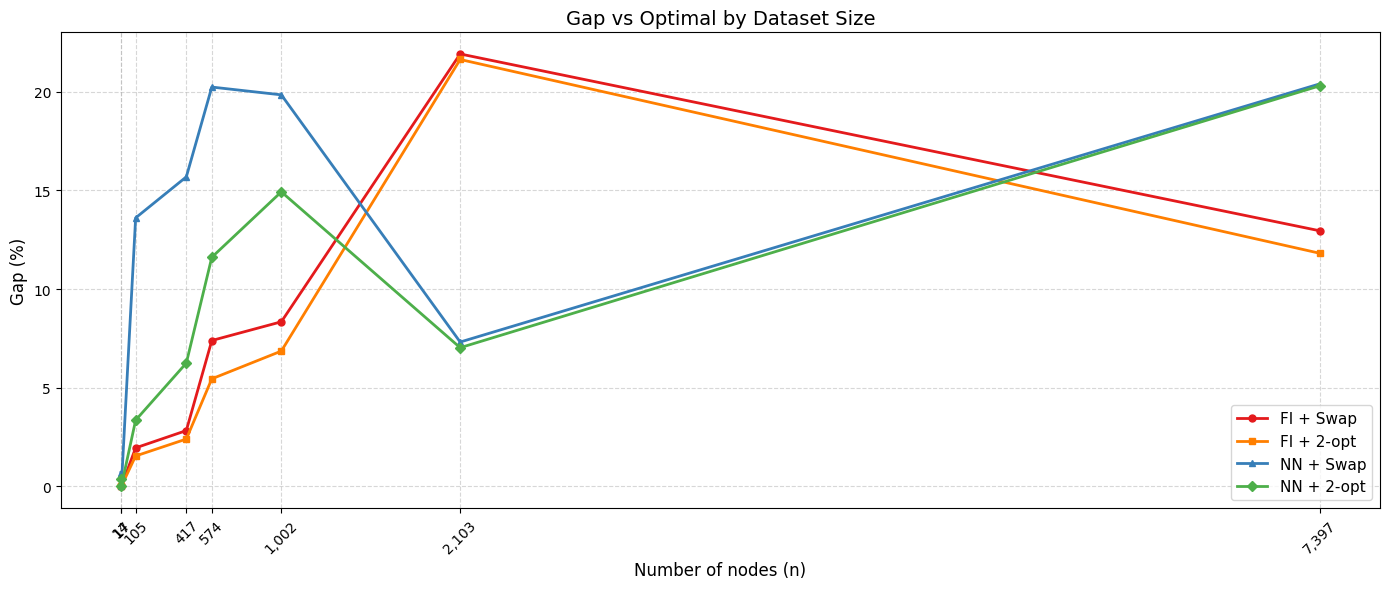

In [ ]:
#Visualize how each pipeline's gap changes as problem size (n) grows
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

#Extract n and best gap for each pipeline across all datasets
ns    = [r['n'] for r in all_swap_results]
fi_sw = [calc_gap(r['best_cost'], r['optimal']) for r in all_swap_results]
fi_2o = [calc_gap(r['best_cost'], r['optimal']) for r in all_fi_2opt_results]
nn_sw = [calc_gap(r['best_cost'], r['optimal']) for r in all_nn_swap_results]
nn_2o = [calc_gap(r['best_cost'], r['optimal']) for r in all_twoopt_results]

fig, ax = plt.subplots(figsize=(14, 6))

#Plot one line per pipeline, each with a distinct color and marker
ax.plot(ns, fi_sw, marker='o', linewidth=2, markersize=5, label='FI + Swap',  color='#e41a1c')
ax.plot(ns, fi_2o, marker='s', linewidth=2, markersize=5, label='FI + 2-opt', color='#ff7f00')
ax.plot(ns, nn_sw, marker='^', linewidth=2, markersize=5, label='NN + Swap',  color='#377eb8')
ax.plot(ns, nn_2o, marker='D', linewidth=2, markersize=5, label='NN + 2-opt', color='#4daf4a')

ax.set_xlabel('Number of nodes (n)', fontsize=12)
ax.set_ylabel('Gap (%)', fontsize=12)
ax.set_title('Gap vs Optimal by Dataset Size', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(ns)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#README

In [ ]:
readme = open('/content/README.md', 'w')
readme.write("""# TSP Solver - Discrete Mathematics Project

## Cách chạy trên Google Colab
1. Mở notebook trên Colab
2. Run All — notebook tự tải dataset và chạy luôn

## Cách chạy trên Local
1. Cài thư viện:
   pip install numpy scipy matplotlib gdown
2. Chạy notebook bình thường, cell đầu sẽ tự tải dataset về

## Dataset
Tải thư mục datasets/ tại: https://drive.google.com/...  ← paste link vào đây
Sau khi tải về, giải nén và đặt thư mục datasets/ cùng chỗ với file notebook

## Cấu trúc thư mục
project/
├── project_discrete_maths.ipynb
├── README.md
└── datasets/
    ├── burma14.tsp
    ├── gr17.tsp
    ├── lin105.tsp
    ├── fl417.tsp
    ├── u574.tsp
    ├── pr1002.tsp
    ├── d2103.tsp
    └── pla7397.tsp

## Cách chạy trên Google Colab
1. Upload thư mục datasets/ lên Google Drive tại đúng đường dẫn: My Drive/datasets/
2. Upload file notebook lên Colab
3. Chạy từng cell theo thứ tự từ trên xuống dưới

## Cách chạy trên máy Local
1. Cài thư viện: pip install numpy scipy matplotlib
2. Đặt thư mục datasets/ cùng chỗ với file notebook
3. Trong cell thứ 2 của notebook, đổi DATASET_DIR thành: './datasets/'
4. Comment 2 dòng đầu tiên của notebook:
   # from google.colab import drive
   # drive.mount('/content/drive')
5. Chạy từng cell theo thứ tự từ trên xuống dưới

## Lưu ý
- Bắt buộc chạy các cell theo thứ tự, không chạy nhảy cóc
- Dataset lớn (d2103, pla7397) có thể mất vài phút
""")
readme.close()
print("Xong!")

Xong!
